In [13]:
from pathlib import Path
import kagglehub

path = Path(kagglehub.dataset_download("garymk/kitti-3d-object-detection-dataset"))
ROOT = next(path.rglob("label_2")).parent
print("Training data:", ROOT)

Training data: /kaggle/input/datasets/garymk/kitti-3d-object-detection-dataset/training


In [14]:
import time
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [15]:
def load_scan(frame: str) -> np.ndarray:
    """(N, 4) array: x forward, y left, z up, intensity."""
    return np.fromfile(ROOT / "velodyne" / f"{frame}.bin", dtype=np.float32).reshape(-1, 4)

points = load_scan("000010")
print(points.shape)

(115875, 4)


In [16]:
def crop(points: np.ndarray, x=(0, 60), y=(-30, 30), z=(-3, 2)) -> np.ndarray:
    """Keep points inside the area of interest (same window as the BEV plots)."""
    keep = ((points[:, 0] >= x[0]) & (points[:, 0] < x[1]) &
            (points[:, 1] >= y[0]) & (points[:, 1] < y[1]) &
            (points[:, 2] >= z[0]) & (points[:, 2] < z[1]))
    return points[keep]

cropped = crop(points)
print(len(points), "->", len(cropped))

115875 -> 52518


In [17]:
def voxel_downsample(points: np.ndarray, size: float = 0.2) -> np.ndarray:
    """Average all points that fall in the same voxel."""
    idx = np.floor(points[:, :3] / size).astype(np.int64)
    idx -= idx.min(axis=0)
    dims = idx.max(axis=0) + 1
    keys = (idx[:, 0] * dims[1] + idx[:, 1]) * dims[2] + idx[:, 2]
    _, inv, counts = np.unique(keys, return_inverse=True, return_counts=True)
    sums = np.zeros((len(counts), points.shape[1]))
    np.add.at(sums, inv.ravel(), points)
    return (sums / counts[:, None]).astype(np.float32)

start = time.perf_counter()
down = voxel_downsample(cropped, 0.2)
print(len(cropped), "->", len(down), f"in {(time.perf_counter() - start) * 1000:.0f} ms")

52518 -> 12245 in 34 ms


In [18]:
# small check: two points in one voxel should become their average
test = np.array([[0.01, 0.01, 0.01, 1], [0.09, 0.09, 0.09, 3], [0.55, 0, 0, 5]], dtype=np.float32)
out = voxel_downsample(test, 0.1)
print(out[np.argsort(out[:, 0])])

# number of voxels should match a slow count with a set
rand = np.random.default_rng(0).uniform(-5, 5, (5000, 4)).astype(np.float32)
print(len(voxel_downsample(rand, 0.5)), len({tuple(v) for v in np.floor(rand[:, :3] / 0.5).astype(int)}))

[[0.05 0.05 0.05 2.  ]
 [0.55 0.   0.   5.  ]]
3719 3719


In [19]:
for size in [0.05, 0.1, 0.2, 0.3, 0.5]:
    print(f"voxel {size:.2f} m  ->  {len(voxel_downsample(cropped, size)):6d} points")

voxel 0.05 m  ->   36164 points
voxel 0.10 m  ->   23274 points
voxel 0.20 m  ->   12245 points
voxel 0.30 m  ->    7712 points
voxel 0.50 m  ->    4084 points


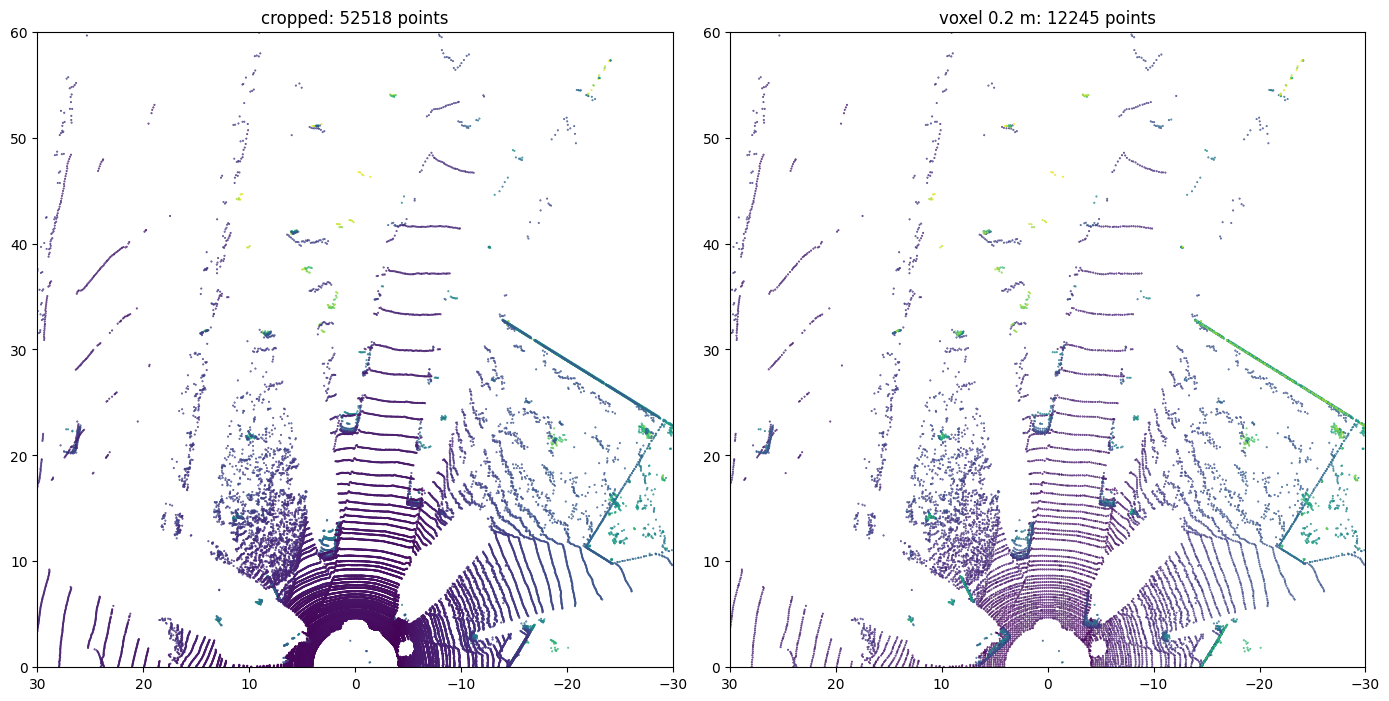

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, pts, name in zip(axes, [cropped, down], ["cropped", "voxel 0.2 m"]):
    ax.scatter(pts[:, 1], pts[:, 0], s=0.2, c=pts[:, 2], cmap="viridis")
    ax.set(xlim=(30, -30), ylim=(0, 60), aspect="equal", title=f"{name}: {len(pts)} points")
plt.tight_layout()
plt.show()

In [21]:
def height_trace(points: np.ndarray) -> go.Scatter3d:
    z = points[:, 2]
    lo, hi = np.percentile(z, [2, 98])
    return go.Scatter3d(x=points[:, 0], y=points[:, 1], z=z, mode="markers", name="points",
                        marker=dict(size=1.2, color=np.clip(z, lo, hi), colorscale="Viridis",
                                    colorbar=dict(title="z (m)")))

def show(traces, title=""):
    fig = go.Figure(traces)
    fig.update_layout(title=title, height=700, margin=dict(l=0, r=0, t=40, b=0),
                      scene=dict(aspectmode="data", camera=dict(eye=dict(x=-1.2, y=0, z=0.8))))
    fig.show()

show([height_trace(down)], "Frame 000010, voxel 0.2 m")

In [22]:
EDGES = [(0, 1), (1, 2), (2, 3), (3, 0), (4, 5), (5, 6), (6, 7), (7, 4),
         (0, 4), (1, 5), (2, 6), (3, 7)]

def box_corners(box: dict) -> np.ndarray:
    """8 corners of a 3D box, bottom four first."""
    l, w, h = box["size"]
    c, s = np.cos(box["yaw"]), np.sin(box["yaw"])
    local = np.array([[l/2, w/2], [l/2, -w/2], [-l/2, -w/2], [-l/2, w/2]])
    xy = local @ np.array([[c, -s], [s, c]]).T + box["centre"][:2]
    bottom = np.c_[xy, np.full(4, box["centre"][2] - h/2)]
    top = np.c_[xy, np.full(4, box["centre"][2] + h/2)]
    return np.vstack([bottom, top])

def box_trace(box: dict, colour="orange") -> go.Scatter3d:
    corners = box_corners(box)
    x, y, z = [], [], []
    for i, j in EDGES:
        x += [corners[i, 0], corners[j, 0], None]
        y += [corners[i, 1], corners[j, 1], None]
        z += [corners[i, 2], corners[j, 2], None]
    return go.Scatter3d(x=x, y=y, z=z, mode="lines", line=dict(color=colour, width=5), name=box["cls"])

In [23]:
# fake car 10 m ahead, sensor is ~1.73 m above the road
fake = {"cls": "fake", "centre": np.array([10.0, 2.0, -1.73 + 0.75]), "size": (3.9, 1.6, 1.5), "yaw": np.deg2rad(15)}
print(box_corners(fake).round(2))

[[11.68  3.28 -1.73]
 [12.09  1.73 -1.73]
 [ 8.32  0.72 -1.73]
 [ 7.91  2.27 -1.73]
 [11.68  3.28 -0.23]
 [12.09  1.73 -0.23]
 [ 8.32  0.72 -0.23]
 [ 7.91  2.27 -0.23]]


In [24]:
show([height_trace(down), box_trace(fake)], "Frame 000010 with a fake box")

In [25]:
full = voxel_downsample(crop(points, x=(-60, 60), y=(-60, 60)), 0.2)
show([height_trace(full), box_trace(fake)], "Frame 000010, full 360")